# 03 · Model evaluation

**Automated Robson Ten-Group Classification and Cesarean Readiness System: ML workstream**

Notebook 02 trained the models and selected one with the pre-registered rule. This notebook asks whether
that model can be trusted:

| # | Section |
|---|---|
| 1 | Interpretation: what drives the predictions |
| 2 | Robustness: internal vs other hospitals vs a later period |
| 3 | Sensitivity: the onset-coded population (outcome leakage) |
| 4 | Deployment model |
| 5 | Complete-case analysis: removing the missing data |
| 6 | Summary of findings |

Predictions describe **current practice**, not clinical need, and are never a recommendation for or against
a cesarean section. Aggregates only, as in notebooks 01 and 02.

In [1]:
from robson_ml import notebook

nb = notebook.setup()  # synthetic data unless ROBSON_NOTEBOOK_MODE=real
show = notebook.show

data: real


In [2]:
import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import roc_auc_score

from robson_ml import deploy, explain, figures
from robson_ml.feature_sets import build_model_data, complete_cases
from robson_ml.features import build_raw_features, load_feature_registry
from robson_ml.ingest import read_workbook, select_sheet
from robson_ml.mapping import load_mapping
from robson_ml.privacy import fmt_count
from robson_ml.select import (
    experiment_config,
    fold_metrics,
    load_runs,
    load_selection_rule,
    run_artifact_table,
    run_fold_params,
    select_configuration,
)

%matplotlib inline

mapping = load_mapping(nb.at(nb.cfg.mapping_path))
raw = select_sheet(read_workbook(nb.raw_path), mapping.sheet).reset_index(drop=True)
classified = pd.read_parquet(nb.classified_path)
registry = load_feature_registry(nb.at(nb.cfg.features_path))
raw_features, _ = build_raw_features(raw, registry)
data = build_model_data(classified, registry, raw_features, "P_pred")
if nb.mode == "synthetic":  # the saved runs exist only on real data
    data_onset = build_model_data(classified, registry, raw_features, "P_pred_onset_coded")
    notebook.train_synthetic(nb, data, data_onset, registry)

runs = load_runs(nb.tracking_uri)
selection = select_configuration(runs, load_selection_rule(nb.selection_rule_path))
chosen = selection.selected
KEY = ["model", "feature_set", "missing_strategy"]
print(f"selected configuration: {chosen['config'] if chosen is not None else 'none'}")

selected configuration: logreg_l2|FS2|M2|S1|P_pred


## 1. Interpretation of the selected model

The selected run's fold models are **rebuilt without re-tuning** (same folds, the tuned hyperparameters
logged for each fold, same calibration); the first table checks that they reproduce the logged held-out
AUCs. Every explanation is computed on each fold's held-out hospital and summarised globally:

* **Permutation importance:** the drop in held-out AUC when one input is shuffled.
* **SHAP:** mean |SHAP| per input (no beeswarm or dependence plots: they draw one point per woman).
* **Robson recovery check:** `previous_cs_count` or the Robson group should rank in the top 3; if neither
  does, a leakage investigation is opened.
* **Partial dependence** for gestational age and parity (averaged predictions only).

These describe what drives **predicted CS under current practice**; they are not causal effects.

In [3]:
SHAP_ROWS = 60 if nb.mode == "synthetic" else explain.SHAP_MAX_ROWS
SHAP_BACKGROUND = 20 if nb.mode == "synthetic" else explain.SHAP_BACKGROUND
PERMUTATION_REPEATS = 2 if nb.mode == "synthetic" else explain.PERMUTATION_REPEATS

fitted = []
if chosen is not None:
    chosen_config = experiment_config(chosen)
    fitted = explain.refit_folds(data, chosen_config, run_fold_params(nb.tracking_uri, chosen["run_id"]))
    x_sel = data.x[explain.model_columns(data, chosen_config)]
    y_sel = data.y
    refit_auc = explain.heldout_auc(fitted, x_sel, y_sel)
    logged = fold_metrics(pd.DataFrame([chosen]), list(refit_auc.index), "auc").iloc[0]
    display(pd.DataFrame({"logged AUC": logged, "rebuilt AUC": refit_auc}).round(4).rename_axis("fold"))

,logged AUC,rebuilt AUC
fold,,
loho_Kibagabaga,0.7081,0.7081
loho_La Croix du sud,0.8190,0.8190
loho_Masaka,0.7134,0.7134
loho_Muhima,0.7692,0.7692


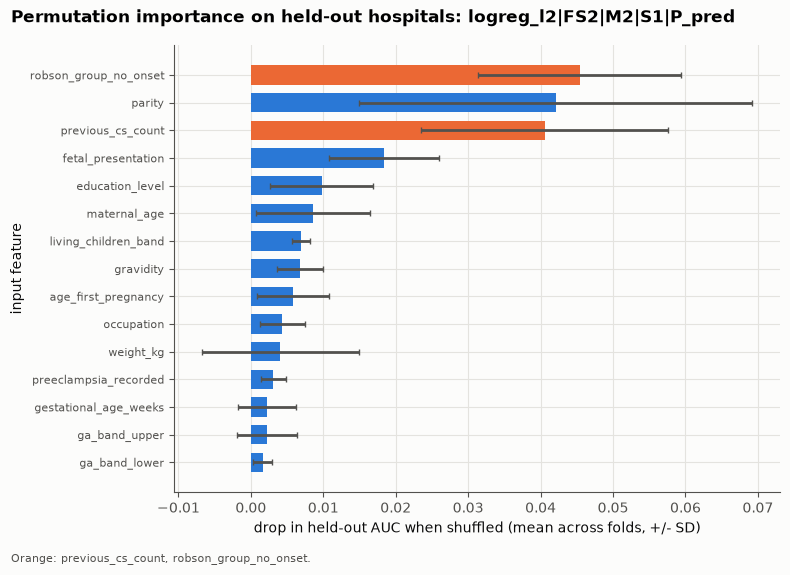

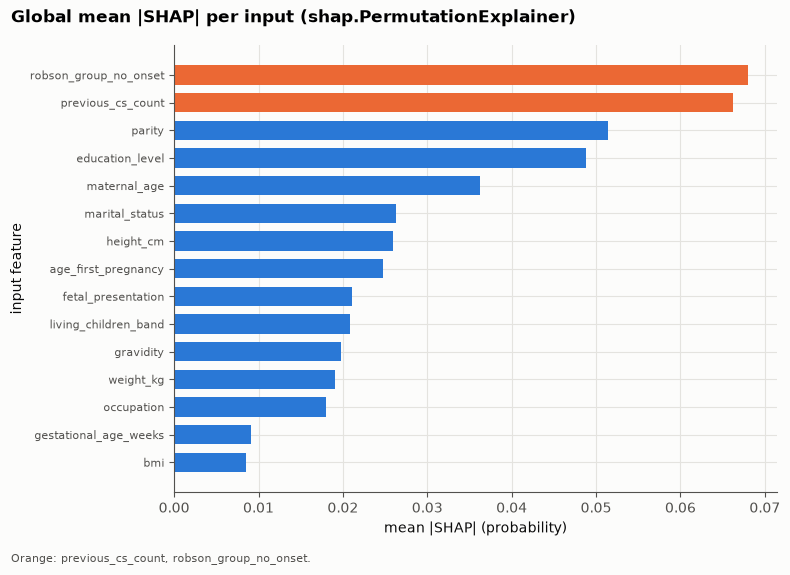

,top 3,Robson feature found,check
SHAP,"robson_group_no_onset, previous_cs_count, parity","previous_cs_count, robson_group_no_onset",passed
permutation,"robson_group_no_onset, parity, previous_cs_count","previous_cs_count, robson_group_no_onset",passed


In [4]:
if fitted:
    permutation = explain.permutation_importances(
        fitted, x_sel, y_sel, n_repeats=PERMUTATION_REPEATS, seed=nb.seed
    )
    show(
        figures.importance_bars(
            permutation,
            "mean",
            f"Permutation importance on held-out hospitals: {chosen['config']}",
            "drop in held-out AUC when shuffled (mean across folds, +/- SD)",
            error="sd",
            highlight=explain.ROBSON_RECOVERY_FEATURES,
        )
    )
    shap_table, shap_method = explain.shap_importance(
        fitted, x_sel, str(chosen["family"]), max_rows=SHAP_ROWS, background=SHAP_BACKGROUND, seed=nb.seed
    )
    show(
        figures.importance_bars(
            shap_table,
            "mean_abs_shap",
            f"Global mean |SHAP| per input ({shap_method})",
            "mean |SHAP| (" + ("log-odds" if chosen["family"] == "tree" else "probability") + ")",
            highlight=explain.ROBSON_RECOVERY_FEATURES,
        )
    )
    recovery = {
        "SHAP": explain.robson_recovery(shap_table["mean_abs_shap"]),
        "permutation": explain.robson_recovery(permutation["mean"]),
    }
    display(
        pd.DataFrame(
            {
                name: {
                    "top 3": ", ".join(check.top),
                    "Robson feature found": ", ".join(check.found) or "none",
                    "check": "passed" if check.passed else "FAILED: open a leakage investigation",
                }
                for name, check in recovery.items()
            }
        ).T
    )

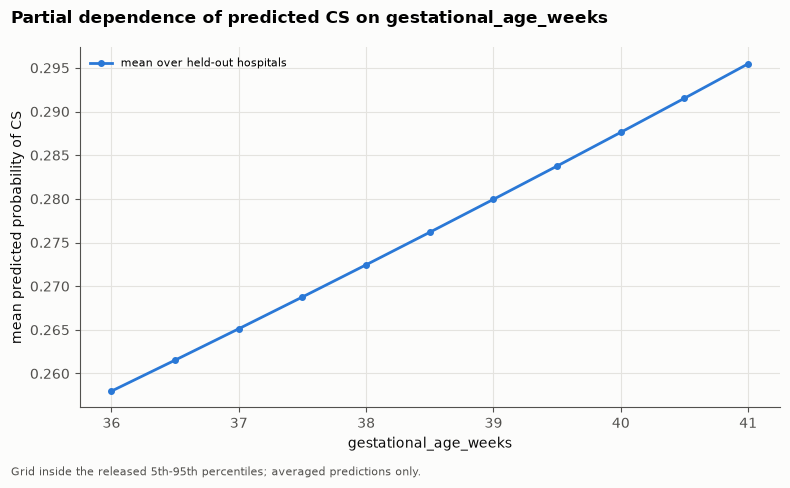

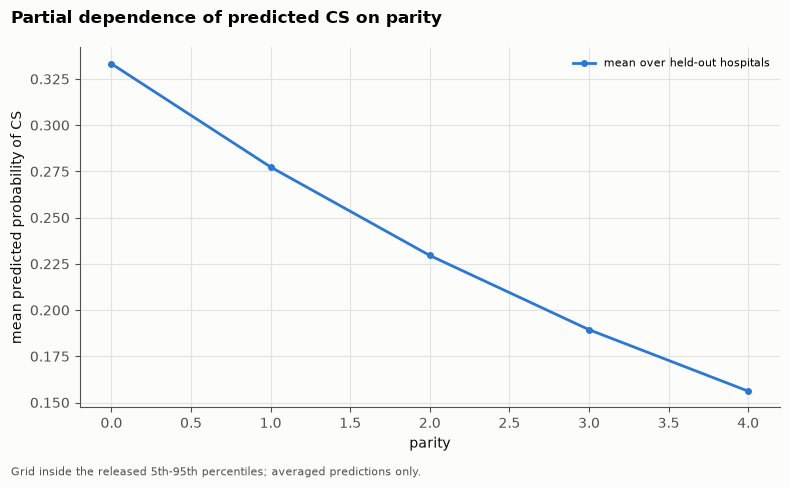

**AUC within each onset-free Robson group: selected model vs B1 (pooled S1)**

,selected AUC (logreg_l2),B1 AUC
robson_group_no_onset,,
10,0.76,0.378
1_2,0.523,0.462
3_4,0.568,0.509
5,0.489,0.291
8,insufficient,insufficient
partial,0.843,0.43


In [5]:
if fitted:
    pdp_curves = {}
    for feature, step in (("gestational_age_weeks", 0.5), ("parity", 1.0)):
        if feature not in x_sel.columns:
            continue
        grid_values = explain.pdp_grid(x_sel[feature], step=step)
        if len(grid_values) >= 2:
            pdp_curves[feature] = explain.partial_dependence(fitted, x_sel, feature, grid_values, seed=nb.seed)
    for feature, curve in pdp_curves.items():
        show(
            figures.line_curves(
                {"mean over held-out hospitals": curve},
                "value",
                "mean",
                f"Partial dependence of predicted CS on {feature}",
                feature,
                "mean predicted probability of CS",
                note="Grid inside the released 5th-95th percentiles; averaged predictions only.",
            )
        )
if chosen is not None and selection.baseline is not None:
    display(Markdown("**AUC within each onset-free Robson group: selected model vs B1 (pooled S1)**"))
    display(
        explain.subgroup_comparison(
            run_artifact_table(nb.tracking_uri, chosen["run_id"], "subgroups.csv"),
            run_artifact_table(nb.tracking_uri, selection.baseline["run_id"], "subgroups.csv"),
            labels=(f"selected AUC ({chosen['model']})", "B1 AUC"),
        )
    )

## 2. Robustness

### 2.1 Internal (S3) vs other hospitals (S1) vs a later period (S4)

S3 is ordinary internal cross-validation (optimistic); S1 holds out a whole hospital in turn; S4 trains on
November-January and tests on February-March. A small gap between S3 and S1 means the model transfers
across hospitals.

In [6]:
if chosen is not None:
    same_spec = (
        (runs[KEY] == chosen[KEY]).all(axis=1)
        & (runs["population"] == "P_pred")
        & runs["split"].isin(["S1", "S3", "S4"])
    )
    by_split = runs[same_spec].set_index("split")[["mean_auc", "mean_calibration_slope", "mean_log_loss"]]
    by_split = by_split.reindex(["S3", "S1", "S4"]).dropna(how="all")
    display(Markdown(f"**{chosen['config']} by split scheme**"))
    display(by_split.round(3))

s1 = runs[(runs["split"] == "S1") & (runs["population"] == "P_pred")]
gap = runs[runs["split"] == "S3"][[*KEY, "mean_auc"]].merge(
    s1[[*KEY, "mean_auc"]], on=KEY, suffixes=(" S3 (internal)", " S1 (other hospitals)")
)
gap["internal - LOHO"] = gap["mean_auc S3 (internal)"] - gap["mean_auc S1 (other hospitals)"]
display(Markdown("**Every configuration run under both S3 and S1**"))
display(gap.set_index(KEY).round(3) if len(gap) else Markdown("_none_"))

**logreg_l2|FS2|M2|S1|P_pred by split scheme**

,mean_auc,mean_calibration_slope,mean_log_loss
split,,,
S3,0.763,1.000,0.470
S1,0.752,0.987,0.501
S4,0.772,1.148,0.462


**Every configuration run under both S3 and S1**

mean_auc S3 (internal)  \
model     feature_set missing_strategy                           
B0        FS0         M0                                 0.500   
B1        FS0         M0                                 0.722   
B2        FS0         M1                                 0.729   
B3        FS4         M1                                 0.763   
logreg_l2 FS2         M2                                 0.763   
          FS4         M1                                 0.764   
                      M2                                 0.763   
mlp       FS4         M1                                 0.761   
                      M2                                 0.765   
xgboost   FS4         M0                                 0.774   
                      M1                                 0.771   
                      M2                                 0.772   

                                        mean_auc S1 (other hospitals)  \
model     feature_set missing_strategy                                  
B0        FS0         M0                                        0.500   
B1        FS0         M0                                        0.730   
B2        FS0         M1                                        0.737   
B3        FS4         M1                                        0.751   
logreg_l2 FS2         M2                                        0.752   
          FS4         M1                                        0.751   
                      M2                                        0.752   
mlp       FS4         M1                                        0.742   
                      M2                                        0.753   
xgboost   FS4         M0                                        0.748   
                      M1                                        0.745   
                      M2                                        0.750   

                                        internal - LOHO  
model     feature_set missing_strategy                   
B0        FS0         M0                          0.000  
B1        FS0         M0                         -0.008  
B2        FS0         M1                         -0.008  
B3        FS4         M1                          0.011  
logreg_l2 FS2         M2                          0.011  
          FS4         M1                          0.013  
                      M2                          0.011  
mlp       FS4         M1                          0.019  
                      M2                          0.012  
xgboost   FS4         M0                          0.025  
                      M1                          0.026  
                      M2                          0.023

### 2.2 Temporal validation of every model (S4)

Every family at FS2/M2 (B1 at FS0) trained on the earlier months and tested on the later period, with its
leave-one-hospital-out AUC for the same specification alongside.

In [7]:
s4 = runs[(runs["split"] == "S4") & (runs["population"] == "P_pred")]
if nb.mode == "real":
    s4 = s4[(s4["model"] == "B1") | ((s4["feature_set"] == "FS2") & (s4["missing_strategy"] == "M2"))]
s4_view = s4.merge(s1[[*KEY, "mean_auc"]].rename(columns={"mean_auc": "S1 AUC"}), on=KEY, how="left")
s4_view = s4_view.set_index("model")[
    ["feature_set", "missing_strategy", "mean_auc", "S1 AUC", "mean_calibration_slope", "mean_brier"]
].rename(columns={"mean_auc": "S4 AUC", "mean_calibration_slope": "S4 slope", "mean_brier": "S4 Brier"})
s4_view.sort_values("S4 AUC", ascending=False).round(3)

,feature_set,missing_strategy,S4 AUC,S1 AUC,S4 slope,S4 Brier
model,,,,,,
ft_transformer,FS2,M2,0.793,0.746,1.191,0.144
xgboost,FS2,M2,0.777,0.751,1.081,0.141
mlp,FS2,M2,0.776,0.737,1.205,0.142
elasticnet,FS2,M2,0.772,0.751,1.138,0.146
logreg_l2,FS2,M2,0.772,0.752,1.148,0.146
random_forest,FS2,M2,0.771,0.753,1.032,0.144
svm_rbf,FS2,M2,0.747,0.714,0.501,0.150
cart,FS2,M2,0.735,0.708,1.307,0.142
B1,FS0,M0,0.725,0.730,1.239,0.150


### 2.3 Local recalibration (S2)

S2 refits only the intercept on each held-out hospital's first 150 admissions. It is evaluated on the rest,
so S1 and S2 are not scored on identical rows: the comparison is indicative.

In [8]:
cols = ["mean_calibration_in_the_large", "mean_calibration_slope", "mean_auc"]
recal = s1[[*KEY, *cols]].merge(runs[runs["split"] == "S2"][[*KEY, *cols]], on=KEY, suffixes=(" S1", " S2"))
recal.set_index(KEY).round(3) if len(recal) else Markdown("_No configuration has both S1 and S2 runs._")

mean_calibration_in_the_large S1  \
model     feature_set missing_strategy                                     
B0        FS0         M0                                           0.117   
B1        FS0         M0                                           0.045   
B2        FS0         M1                                           0.024   
B3        FS4         M1                                           0.039   
logreg_l2 FS4         M1                                           0.053   
                      M2                                           0.052   
mlp       FS4         M1                                          -0.007   
                      M2                                          -0.001   
xgboost   FS4         M0                                           0.010   
                      M1                                           0.015   
                      M2                                           0.010   

                                        mean_calibration_slope S1  \
model     feature_set missing_strategy                              
B0        FS0         M0                             1.659149e+13   
B1        FS0         M0                             1.048000e+00   
B2        FS0         M1                             1.006000e+00   
B3        FS4         M1                             9.790000e-01   
logreg_l2 FS4         M1                             9.840000e-01   
                      M2                             9.840000e-01   
mlp       FS4         M1                             9.140000e-01   
                      M2                             9.570000e-01   
xgboost   FS4         M0                             9.540000e-01   
                      M1                             9.450000e-01   
                      M2                             9.800000e-01   

                                        mean_auc S1  \
model     feature_set missing_strategy                
B0        FS0         M0                      0.500   
B1        FS0         M0                      0.730   
B2        FS0         M1                      0.737   
B3        FS4         M1                      0.751   
logreg_l2 FS4         M1                      0.751   
                      M2                      0.752   
mlp       FS4         M1                      0.742   
                      M2                      0.753   
xgboost   FS4         M0                      0.748   
                      M1                      0.745   
                      M2                      0.750   

                                        mean_calibration_in_the_large S2  \
model     feature_set missing_strategy                                     
B0        FS0         M0                                           0.028   
B1        FS0         M0                                           0.197   
B2        FS0         M1                                           0.073   
B3        FS4         M1                                          -0.113   
logreg_l2 FS4         M1                                          -0.116   
                      M2                                          -0.118   
mlp       FS4         M1                                          -0.108   
                      M2                                          -0.107   
xgboost   FS4         M0                                          -0.004   
                      M1                                           0.055   
                      M2                                           0.037   

                                        mean_calibration_slope S2  mean_auc S2  
model     feature_set missing_strategy                                          
B0        FS0         M0                            -3.649675e+12        0.500  
B1        FS0         M0                             1.132000e+00        0.730  
B2        FS0         M1                             1.001000e+00        0.734  
B3        FS4         M1                   

## 3. Sensitivity: onset-coded population vs `P_pred`

The same models on the earlier onset-coded population, with `onset_of_labour` as a feature. Onset is often
coded only once a caesarean has happened (notebook 01, section 4.6), so a model that reads it is partly
reading the outcome.

In [9]:
onset = runs[(runs["split"] == "S1") & (runs["population"] == "P_pred_onset_coded")]
sensitivity = onset.merge(s1, on=KEY, suffixes=(" (onset-coded)", " (P_pred)"))
if len(sensitivity):
    sensitivity = sensitivity.set_index(KEY)[
        ["mean_auc (P_pred)", "mean_auc (onset-coded)",
         "mean_calibration_slope (P_pred)", "mean_calibration_slope (onset-coded)"]
    ]
    display(sensitivity.round(3))

mean_auc (P_pred)  \
model     feature_set missing_strategy                      
logreg_l2 FS4         M1                            0.751   
                      M2                            0.752   
mlp       FS4         M1                            0.742   
                      M2                            0.753   
xgboost   FS4         M0                            0.748   
                      M1                            0.745   
                      M2                            0.750   

                                        mean_auc (onset-coded)  \
model     feature_set missing_strategy                           
logreg_l2 FS4         M1                                 0.749   
                      M2                                 0.757   
mlp       FS4         M1                                 0.773   
                      M2                                 0.773   
xgboost   FS4         M0                                 0.791   
                      M1                                 0.772   
                      M2                                 0.784   

                                        mean_calibration_slope (P_pred)  \
model     feature_set missing_strategy                                    
logreg_l2 FS4         M1                                          0.984   
                      M2                                          0.984   
mlp       FS4         M1                                          0.914   
                      M2                                          0.957   
xgboost   FS4         M0                                          0.954   
                      M1                                          0.945   
                      M2                                          0.980   

                                        mean_calibration_slope (onset-coded)  
model     feature_set missing_strategy                                        
logreg_l2 FS4         M1                                               0.723  
                      M2                                               0.717  
mlp       FS4         M1                                               0.613  
                      M2                                               0.679  
xgboost   FS4         M0                                               0.835  
                      M1                                               0.717  
                      M2                                               0.814

On the onset-coded population the AUC is **higher** for most models, but the calibration slope **drops well
below 1** (0.61-0.84 against 0.91-0.98 on `P_pred`): the predictions become overconfident. That combination
is the signature of **outcome leakage**, not better discrimination. The onset-coded population is therefore
kept only as a sensitivity check, never as a candidate.

## 4. Deployment model

`facility_id` may be a feature only in the single deployment fit (S5), and only if it lowers the selected
specification's internal (S3) log loss. Real mode reads the artefact written by `robson-ml fit-deploy`;
synthetic mode fits a small one here.

In [10]:
# 4.1 Does the deployment model use facility_id? (decided by the S3 log loss rule)
facility_decision = None
if chosen is not None:
    try:
        facility_decision = deploy.deployment_feature_choice(
            nb.tracking_uri,
            model=str(chosen["model"]),
            feature_set=str(chosen["feature_set"]),
            missing_strategy=str(chosen["missing_strategy"]),
            population=str(chosen["population"]),
        )
        print(f"deployment-variant decision: {facility_decision['rule']}")
        print(f"choice: {facility_decision['chosen_feature_set']} (use_facility={facility_decision['use_facility']})")
    except LookupError as exc:
        print(f"deployment-variant decision: not available ({exc})")

deployment-variant decision: facility used only if the deploy variant's S3 mean log loss is lower
choice: FS2_deploy (use_facility=True)


In [11]:
# 4.2 The deployment artefact: fitted here in synthetic mode, read from artefacts/ on real data.
summary, facility_table = None, None
if nb.mode == "synthetic" and facility_decision is not None:
    ctx = notebook.run_context(nb, registry)
    deploy_config = deploy.DeploymentConfig(
        model=str(chosen["model"]),
        feature_set=str(chosen["feature_set"]),
        use_facility=bool(facility_decision["use_facility"]),
        missing_strategy=str(chosen["missing_strategy"]),
        population=str(chosen["population"]),
        seed=nb.seed,
        n_trials=2,
        version_label="synthetic-demo",
    )
    provenance = deploy.Provenance(
        tracking_uri=nb.tracking_uri,
        data_hash=ctx.data_hash,
        features_yaml_hash=ctx.features_yaml_hash,
        git_commit=ctx.git_commit,
        selection_rule_commit=ctx.selection_rule_commit,
    )
    result = deploy.fit_deployment(
        deploy_config, data, provenance, nb.root / "artefacts", deploy_config.use_facility, facility_decision
    )
    summary = result.summary
    if "facility_contribution" in summary:
        facility_table = pd.DataFrame(summary["facility_contribution"])
elif nb.mode == "real":
    dcfg = deploy.load_deployment_config(nb.root / "configs" / "deployment.yaml")
    summary_path = nb.repo / "artefacts" / dcfg.version_label / deploy.SUMMARY_FILE
    if summary_path.exists():
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
    facility_csv = nb.reports / "interpretation" / "facility_contribution.csv"
    if facility_csv.exists():
        facility_table = pd.read_csv(facility_csv)

if summary is not None:
    display(
        pd.DataFrame(
            {
                "value": {
                    "version label": summary["version_label"],
                    "algorithm": summary["algorithm"],
                    "feature set": summary["feature_set"],
                    "calibration method": summary["calibration"]["method"],
                    "fit rows": summary["n_fit_rows"],
                    "calibration rows": summary["n_calibration_rows"],
                    "training window": f"{summary['training_window_start']} to {summary['training_window_end']}",
                }
            }
        ).rename_axis("deployment artefact")
    )

,value
deployment artefact,
version label,readiness-v1.0
algorithm,logreg_l2
feature set,FS2_deploy
calibration method,platt
fit rows,3412
calibration rows,853
training window,2023-11 to 2024-03


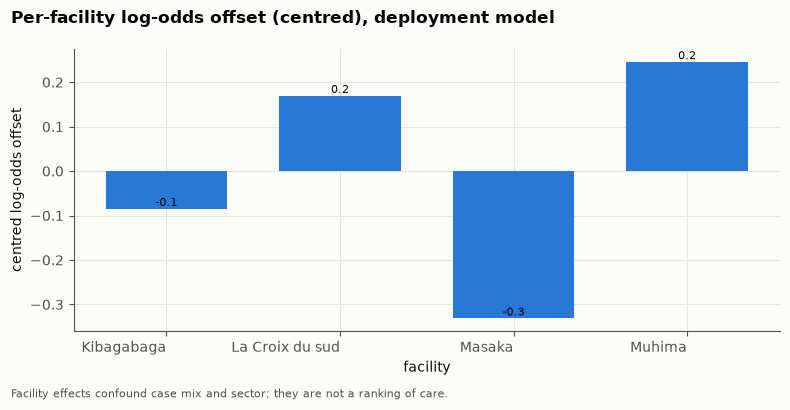

In [12]:
# 4.3 Per-facility offsets (only for a linear model that uses facility_id).
if facility_table is not None:
    show(
        figures.bar_chart(
            facility_table["facility_id"].astype(str).tolist(),
            facility_table["centred"].tolist(),
            "Per-facility log-odds offset (centred), deployment model",
            "facility",
            "centred log-odds offset",
            note="Facility effects confound case mix and sector; they are not a ranking of care.",
        )
    )

## 5. Complete-case analysis: removing the missing data

Instead of imputing, drop every admission with any missing input in the feature set, then train and
evaluate on what is left with the same folds, tuning, calibration and metrics. FS3 is left out (its
missing-value flags are all 0 on complete cases, so it equals FS2).

,admissions kept,% of P_pred,CS rate kept (%)
feature set,,,
FS0,2799,65.6,27.1
FS1,1301,30.5,29.0
FS2,824,19.3,27.7


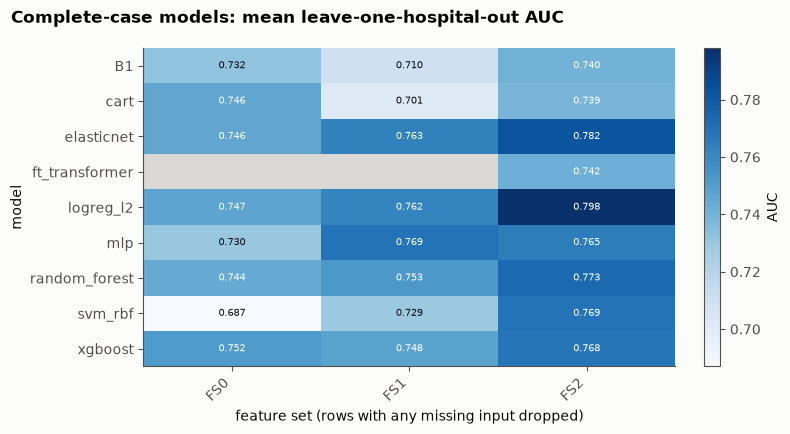

In [13]:
CC_SETS = ("FS0", "FS1", "FS2")
cc_data = {name: complete_cases(data, name) for name in CC_SETS}
display(
    pd.DataFrame(
        [
            {
                "feature set": name,
                "admissions kept": fmt_count(len(subset.y)),
                "% of P_pred": round(100 * len(subset.y) / len(data.y), 1),
                "CS rate kept (%)": round(100 * float(subset.y.mean()), 1),
            }
            for name, subset in cc_data.items()
        ]
    ).set_index("feature set")
)
cc_runs = runs[(runs["split"] == "S1") & (runs["population"] == "P_pred_complete")]
if len(cc_runs):
    show(
        figures.heatmap(
            cc_runs.pivot_table(index="model", columns="feature_set", values="mean_auc").round(3),
            "Complete-case models: mean leave-one-hospital-out AUC",
            "feature set (rows with any missing input dropped)",
            "model",
            "AUC",
            fmt="{:.3f}",
        )
    )

**Imputation vs complete cases on the same admissions.** For each model and feature set: the imputed
model on all rows; the same imputed predictions scored only on the complete-case admissions; and the
complete-case model. The last two are scored on exactly the same admissions, so their difference is the
effect of dropping incomplete admissions from training instead of filling them in.

In [14]:
def mean_fold_auc(oof: pd.DataFrame) -> float:
    # Mean over held-out hospitals of the AUC; a hospital with one outcome class is skipped.
    aucs = [roc_auc_score(g["y"], g["p"]) for _, g in oof.groupby("fold") if g["y"].nunique() == 2]
    return float(np.mean(aucs)) if aucs else float("nan")


ORDER = {"M2": 0, "M1": 1, "M0": 2}
compare_rows = []
for _, cc_run in cc_runs.iterrows():
    candidates = s1[(s1["model"] == cc_run["model"]) & (s1["feature_set"] == cc_run["feature_set"])]
    if candidates.empty:
        continue
    imputed = candidates.sort_values("missing_strategy", key=lambda s: s.map(ORDER)).iloc[0]
    oof = nb.load_oof(imputed["run_id"], columns=("admission_id", "fold", "y", "p"))
    keep = set(cc_data[cc_run["feature_set"]].meta["admission_id"])
    compare_rows.append(
        {
            "feature set": cc_run["feature_set"],
            "model": cc_run["model"],
            "imputation": imputed["missing_strategy"],
            "imputed, all rows": float(imputed["mean_auc"]),
            "imputed, complete-case rows": mean_fold_auc(oof[oof["admission_id"].isin(keep)])
            if oof is not None
            else float("nan"),
            "complete-case model": float(cc_run["mean_auc"]),
        }
    )
comparison_cc = pd.DataFrame(compare_rows)
if len(comparison_cc):
    comparison_cc["complete-case minus imputed (same rows)"] = (
        comparison_cc["complete-case model"] - comparison_cc["imputed, complete-case rows"]
    )
    comparison_cc = comparison_cc.set_index(["feature set", "model"]).sort_index()
    display(comparison_cc.round(3))
    diff = comparison_cc.drop(index="B1", level="model", errors="ignore")[
        "complete-case minus imputed (same rows)"
    ]
    diff = diff.dropna()
    if len(diff):
        print(
            f"complete-case minus imputed on the same admissions (non-baseline models): "
            f"mean {diff.mean():+.3f} AUC, range {diff.min():+.3f} to {diff.max():+.3f}"
        )

imputation  imputed, all rows  \
feature set model                                          
FS0         B1                     M0              0.730   
            logreg_l2              M2              0.737   
            mlp                    M2              0.737   
            xgboost                M2              0.742   
FS1         logreg_l2              M2              0.750   
            mlp                    M2              0.742   
            xgboost                M2              0.750   
FS2         cart                   M2              0.708   
            elasticnet             M2              0.751   
            ft_transformer         M2              0.746   
            logreg_l2              M2              0.752   
            mlp                    M2              0.737   
            random_forest          M2              0.753   
            svm_rbf                M2              0.714   
            xgboost                M2              0.751   

                            imputed, complete-case rows  complete-case model  \
feature set model                                                              
FS0         B1                                    0.737                0.732   
            logreg_l2                             0.748                0.747   
            mlp                                   0.745                0.730   
            xgboost                               0.751                0.752   
FS1         logreg_l2                             0.769                0.762   
            mlp                                   0.762                0.769   
            xgboost                               0.759                0.748   
FS2         cart                                  0.750                0.739   
            elasticnet                            0.797                0.782   
            ft_transformer                        0.768                0.742   
            logreg_l2                             0.801                0.798   
            mlp                                   0.782                0.765   
            random_forest                         0.775                0.773   
            svm_rbf                               0.765                0.769   
            xgboost                               0.776                0.768   

                            complete-case minus imputed (same rows)  
feature set model                                                    
FS0         B1                                               -0.005  
            logreg_l2                                        -0.001  
            mlp                                              -0.015  
            xgboost                                           0.001  
FS1         logreg_l2                                        -0.007  
            mlp                                               0.006  
            xgboost                                          -0.011  
FS2         cart                                             -0.011  
            elasticnet                                       -0.015  
            ft_transformer                                   -0.026  
            logreg_l2                                        -0.002  
            mlp                                              -0.018  
            random_forest                                    -0.003  
            svm_rbf                                           0.004  
            xgboost                                          -0.008

complete-case minus imputed on the same admissions (non-baseline models): mean -0.007 AUC, range -0.026 to +0.006


## 6. Summary of findings

Figures are from the real-data run.

* **Robson classification.** 94.4% of the 5,520 deliveries are classified into a single Robson group
  automatically; no record is contradictory (notebook 01).
* **Data quality.** The onset-of-labour field is filled in after the fact at two hospitals, so it is excluded
  from every model; parity is derived from previous vaginal and caesarean deliveries.
* **Selected model.** L2 logistic regression on FS2 with iterative imputation (`logreg_l2|FS2|M2`), chosen by
  the pre-registered rule: mean AUC 0.752 on unseen hospitals (0.71-0.82 across the four), calibration slope
  0.99. It passes the baseline check against the Robson lookup (B1, 0.730).
* **The Robson group carries most of the signal.** Admission data add about 0.02 AUC beyond the Robson
  lookup. The limit is what the data record (no blood pressure, glucose, dilation or fetal weight), not the
  algorithm: eight model families, from a single tree to an FT-Transformer, all land between 0.71 and 0.75
  (notebook 02, sections 6-8).
* **Robustness.** On a later period (S4) the selected model scores AUC 0.772 against 0.725 for B1. The
  internal cross-validated AUC (0.763) is only slightly above the leave-one-hospital-out AUC.
* **Missing data.** Removing every admission with a missing input keeps only 19-66% of admissions and makes
  the models slightly worse on the same patients. Imputation is the better choice.
* **Interpretation.** Predictions describe current practice, not clinical need, and are never a
  recommendation for or against a caesarean section.